In [91]:
# !pip install lightkurve
%matplotlib inline
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np

In [92]:
search_result = lk.search_lightcurve("Kepler-9", mission="Kepler")
search_result


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 01,2009,Kepler,1800,kplr003323887,0.0
1,Kepler Quarter 02,2009,Kepler,1800,kplr003323887,0.0
2,Kepler Quarter 03,2009,Kepler,1800,kplr003323887,0.0
3,Kepler Quarter 07,2010,Kepler,60,kplr003323887,0.0
4,Kepler Quarter 07,2010,Kepler,60,kplr003323887,0.0
5,Kepler Quarter 07,2010,Kepler,60,kplr003323887,0.0
6,Kepler Quarter 04,2010,Kepler,1800,kplr003323887,0.0
7,Kepler Quarter 05,2010,Kepler,1800,kplr003323887,0.0
8,Kepler Quarter 06,2010,Kepler,1800,kplr003323887,0.0


In [93]:
light_curve_q3 = lk.search_lightcurve("Kepler-9", mission="Kepler", quarter=3)
#light_curve_q3 # has two rows; I only want first row, quarter 3
lc = light_curve_q3.download()
#lc
lc = lc.flatten(window_length=401)
lc_binned = lc.bin(time_bin_size=0.1)

C:\Users\dwzlo\anaconda3\Lib\site-packages\lightkurve\search.py:420: LightkurveWarning: Warning: 2 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


In [94]:
lc.time
lc.flux #4140 values

<MaskedQuantity [       ———, 1.00165913, 1.00155202, ..., 1.0003524 ,
                 1.00048821, 1.00042822]>

In [95]:
#theoretical
kepler_9b_period = 19.24 # as per NASA Exoplanet Archive
idx = np.arange(lc.time[0], lc.time[4139], kepler_9b_period); 
idxs = np.round(idx).astype(int)

kepler_9b_transit_depth = 0.005 # couldn't find on NASA expoplanet but eyeballing via graph.
lc_theo = np.ones(4140) - kepler_9b_transit_depth;

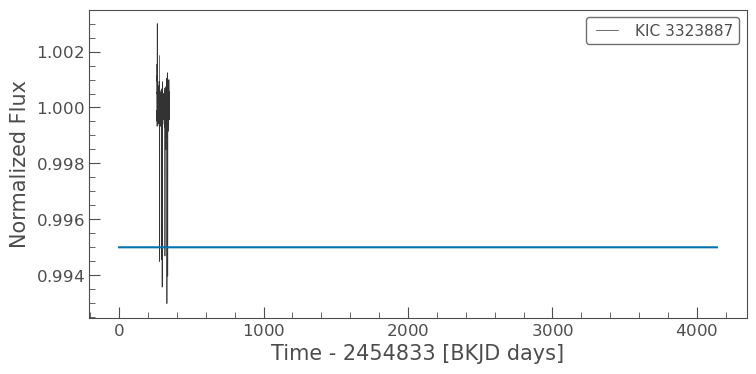

In [96]:
lc_binned.plot()
plt.plot(lc_theo);
plt.show()